In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
movies_df = pd.read_csv('movies.csv')
rating_df=pd.read_csv('ratings.csv')

In [3]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  87585 non-null  int64 
 1   title    87585 non-null  object
 2   genres   87585 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB


In [4]:
rating_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 976.6 MB


In [5]:
rating_df

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858
...,...,...,...,...
32000199,200948,79702,4.5,1294412589
32000200,200948,79796,1.0,1287216292
32000201,200948,80350,0.5,1294412671
32000202,200948,80463,3.5,1350423800


In [6]:
movies_df

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
87580,292731,The Monroy Affaire (2022),Drama
87581,292737,Shelter in Solitude (2023),Comedy|Drama
87582,292753,Orca (2023),Drama
87583,292755,The Angry Breed (1968),Drama


In [7]:
rating_df.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [8]:
movies_df.describe().T

,count,mean,std,min,25%,50%,75%,max
movieId,87585.0,157651.365519,79013.402099,1.0,112657.0,165741.0,213203.0,292757.0


In [9]:
movies_df.duplicated().sum()

np.int64(0)

In [10]:
rating_df.duplicated().sum()

np.int64(0)

In [11]:
movies_df['genres'] = movies_df['genres'].fillna('')

In [12]:
mrg_df=pd.merge(movies_df,rating_df,on='movieId')

In [13]:
mrg_df

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,10,2.5,1169265231
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,11,3.0,850085076
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.0,1027305751
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,19,3.0,974704488
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,20,5.0,1553184230
...,...,...,...,...,...,...
32000199,292731,The Monroy Affaire (2022),Drama,50685,4.0,1697074779
32000200,292737,Shelter in Solitude (2023),Comedy|Drama,165364,1.5,1697145947
32000201,292753,Orca (2023),Drama,150812,4.0,1697140530
32000202,292755,The Angry Breed (1968),Drama,91097,1.0,1697144928


In [14]:
mrg_df.columns

Index(['movieId', 'title', 'genres', 'userId', 'rating', 'timestamp'], dtype='object')

data analysis

In [15]:
top_rating=mrg_df.groupby('title')['rating'].mean().sort_values(ascending=False)

In [16]:
top_rating

title
Prep School (2016)                   5.0
Lost Rivers (2013)                   5.0
Lost Woods (2012)                    5.0
Sweet Kill (1972)                    5.0
Sweet Home Carolina (2017)           5.0
                                    ... 
Słaba płeć? (2015)                   0.5
Rock & Roll Revival                  0.5
Night of the Howling Beast (1975)    0.5
The Speed Spook (1924)               0.5
Tokyo Rose (1946)                    0.5
Name: rating, Length: 84239, dtype: float64

In [17]:
tr_df=pd.DataFrame(top_rating)

In [18]:
tr_df.head(10)

,rating
title,
Prep School (2016),5.0
Lost Rivers (2013),5.0
Lost Woods (2012),5.0
Sweet Kill (1972),5.0
Sweet Home Carolina (2017),5.0
Feminism WTF (2023),5.0
Female Misbehavior (1992),5.0
"Fell, Jumped or Pushed (2016)",5.0
Sweet Carolina (2021),5.0


most popular movies

In [19]:
most_popular=mrg_df.groupby('title')['rating'].count().sort_values(ascending=False)

In [20]:
mp_df=pd.DataFrame(most_popular)

In [21]:
mp_df.head(10)


,rating
title,
"Shawshank Redemption, The (1994)",102929
Forrest Gump (1994),100296
Pulp Fiction (1994),98409
"Matrix, The (1999)",93808
"Silence of the Lambs, The (1991)",90330
Star Wars: Episode IV - A New Hope (1977),85010
Fight Club (1999),77332
Jurassic Park (1993),75233
Schindler's List (1993),73849


rating distribution

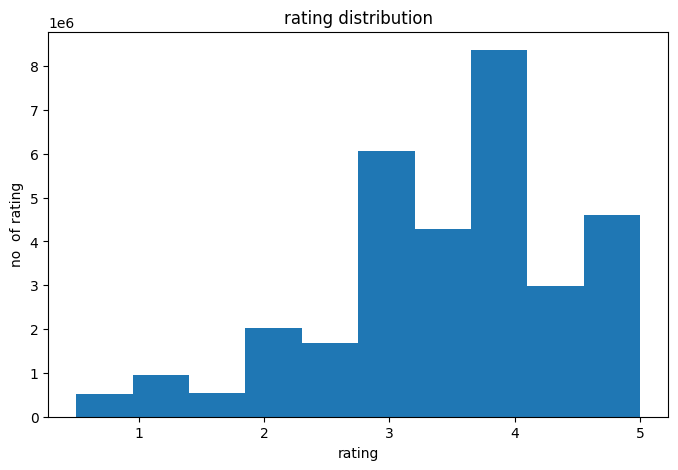

In [22]:
plt.figure(figsize=(8,5))
plt.hist(mrg_df['rating'])
plt.xlabel('rating')
plt.ylabel('no  of rating')
plt.title('rating distribution')
plt.show()
         

In [23]:
genre= movies_df['genres'].str.split('|').explode()

In [24]:
genre_count= genre.value_counts()

In [25]:
genre_count

genres
Drama                 34175
Comedy                23124
Thriller              11823
Romance               10369
Action                 9668
Documentary            9363
Horror                 8654
(no genres listed)     7080
Crime                  6976
Adventure              5402
Sci-Fi                 4907
Animation              4617
Children               4520
Mystery                4013
Fantasy                3851
War                    2325
Western                1696
Musical                1059
Film-Noir               353
IMAX                    195
Name: count, dtype: int64

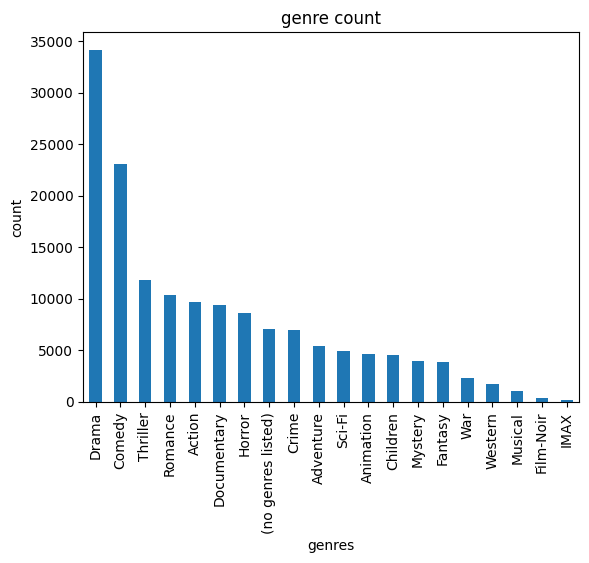

In [26]:
genre_count.plot(kind='bar')
plt.xlabel('genres')
plt.ylabel('count')
plt.title('genre count')
plt.show()

year analysis

In [27]:
movies_df['year']=movies_df['title'].str.extract(r'\((\d{4})\)')

In [28]:
movies_df

,movieId,title,genres,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men (1995),Comedy|Romance,1995
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II (1995),Comedy,1995
...,...,...,...,...
87580,292731,The Monroy Affaire (2022),Drama,2022
87581,292737,Shelter in Solitude (2023),Comedy|Drama,2023
87582,292753,Orca (2023),Drama,2023
87583,292755,The Angry Breed (1968),Drama,1968


In [29]:
movies_per_year= movies_df['year'].value_counts().sort_index()


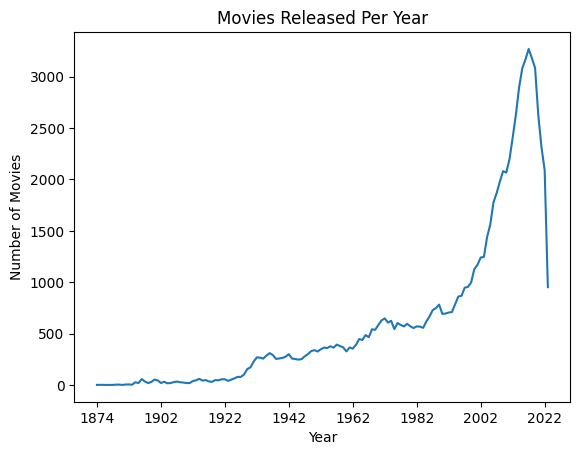

In [30]:
movies_per_year.plot()

plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.title("Movies Released Per Year")

plt.show()

now building mRS

In [31]:
movies_data = movies_df[['movieId', 'title', 'genres']]
movies_data

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
87580,292731,The Monroy Affaire (2022),Drama
87581,292737,Shelter in Solitude (2023),Comedy|Drama
87582,292753,Orca (2023),Drama
87583,292755,The Angry Breed (1968),Drama


In [32]:
movies_data['genres']=movies_data['genres'].fillna('')

C:\Users\Hp\AppData\Local\Temp\ipykernel_5284\1959414892.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_data['genres']=movies_data['genres'].fillna('')


In [33]:
import seaborn as sns

# Text Processing
from sklearn.feature_extraction.text import CountVectorizer

# Similarity Calculation
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [34]:
cv=CountVectorizer(tokenizer=lambda x:x.split('|'))
count_matrix=cv.fit_transform(movies_data['genres'])
print(count_matrix)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 154170 stored elements and shape (87585, 20)>
  Coords	Values
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 5)	1
  (0, 9)	1
  (1, 2)	1
  (1, 4)	1
  (1, 9)	1
  (2, 5)	1
  (2, 15)	1
  (3, 5)	1
  (3, 15)	1
  (3, 8)	1
  (4, 5)	1
  (5, 1)	1
  (5, 6)	1
  (5, 17)	1
  (6, 5)	1
  (6, 15)	1
  (7, 2)	1
  (7, 4)	1
  (8, 1)	1
  (9, 2)	1
  (9, 1)	1
  (9, 17)	1
  :	:
  (87567, 7)	1
  (87568, 8)	1
  (87568, 18)	1
  (87569, 7)	1
  (87570, 7)	1
  (87571, 7)	1
  (87572, 5)	1
  (87572, 1)	1
  (87573, 8)	1
  (87574, 5)	1
  (87574, 8)	1
  (87575, 8)	1
  (87576, 0)	1
  (87577, 17)	1
  (87577, 11)	1
  (87578, 7)	1
  (87579, 8)	1
  (87580, 8)	1
  (87581, 5)	1
  (87581, 8)	1
  (87582, 8)	1
  (87583, 8)	1
  (87584, 2)	1
  (87584, 1)	1
  (87584, 7)	1


In [35]:
print(count_matrix.shape)

(87585, 20)


In [36]:
tfidf=TfidfVectorizer(token_pattern=r'[^|]+')

In [37]:
tfidf

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'[^|]+'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"


In [38]:
tfidf_matrix=tfidf.fit_transform(movies_df['genres'])
tfidf_matrix
                                 

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 154170 stored elements and shape (87585, 20)>

In [39]:
model = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

model.fit(tfidf_matrix)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [40]:
def recommend(movie_name):

   
    movie_name = movie_name.strip().lower()

    
    idx = movies_df[
        movies_df['title'].str.strip().str.lower() == movie_name
    ].index

    
    if len(idx) == 0:
        idx = movies_df[
            movies_df['title'].str.strip().str.lower().str.contains(
                movie_name,
                na=False
            )
        ].index

    if len(idx) == 0:
        return ["Movie not found!"]

    idx = idx[0]

    distances, indices = model.kneighbors(
        tfidf_matrix[idx],
        n_neighbors=11
    )

    recommendations = []

    for i in range(1, len(indices[0])):
        movie_idx = indices[0][i]
        recommendations.append(
            movies_df.iloc[movie_idx]['title']
        )

    return recommendations
    
    

In [41]:
recommend("Moana (2016)")

['Boxtrolls, The (2014)',
 'Missing Link (2019)',
 'Wonder Park (2019)',
 'Toy Story Toons: Small Fry (2011)',
 'Toy Story Toons: Hawaiian Vacation (2011)',
 'The Dragon Spell (2016)',
 'The Good Dinosaur (2015)',
 'Wild, The (2006)',
 'Monsters, Inc. (2001)',
 'The Monkey King (2023)']

In [42]:
recommend("Toy Story (1995)")

['Boxtrolls, The (2014)',
 'Missing Link (2019)',
 'Wonder Park (2019)',
 'Toy Story Toons: Small Fry (2011)',
 'Toy Story Toons: Hawaiian Vacation (2011)',
 'The Dragon Spell (2016)',
 'The Good Dinosaur (2015)',
 'Wild, The (2006)',
 'Monsters, Inc. (2001)',
 'The Monkey King (2023)']

In [43]:
recommend("The Monkey king")

['The Monkey King (2014)',
 'HOUBA! On the Trail of the Marsupilami (Sur la piste du Marsupilami) (2012)',
 'Chinese Zodiac (Armour of God III) (CZ12) (2012)',
 'Flying Swords of Dragon Gate, The (Long men fei jia) (2011)',
 'Kung Fu Panda 2 (2011)',
 'Madagascar: Escape 2 Africa (2008)',
 'Mortal Instruments: City of Bones, The (2013)',
 'Fly Me to the Moon (2008)',
 'Mission: Impossible - Ghost Protocol (2011)',
 'Skyfall (2012)']

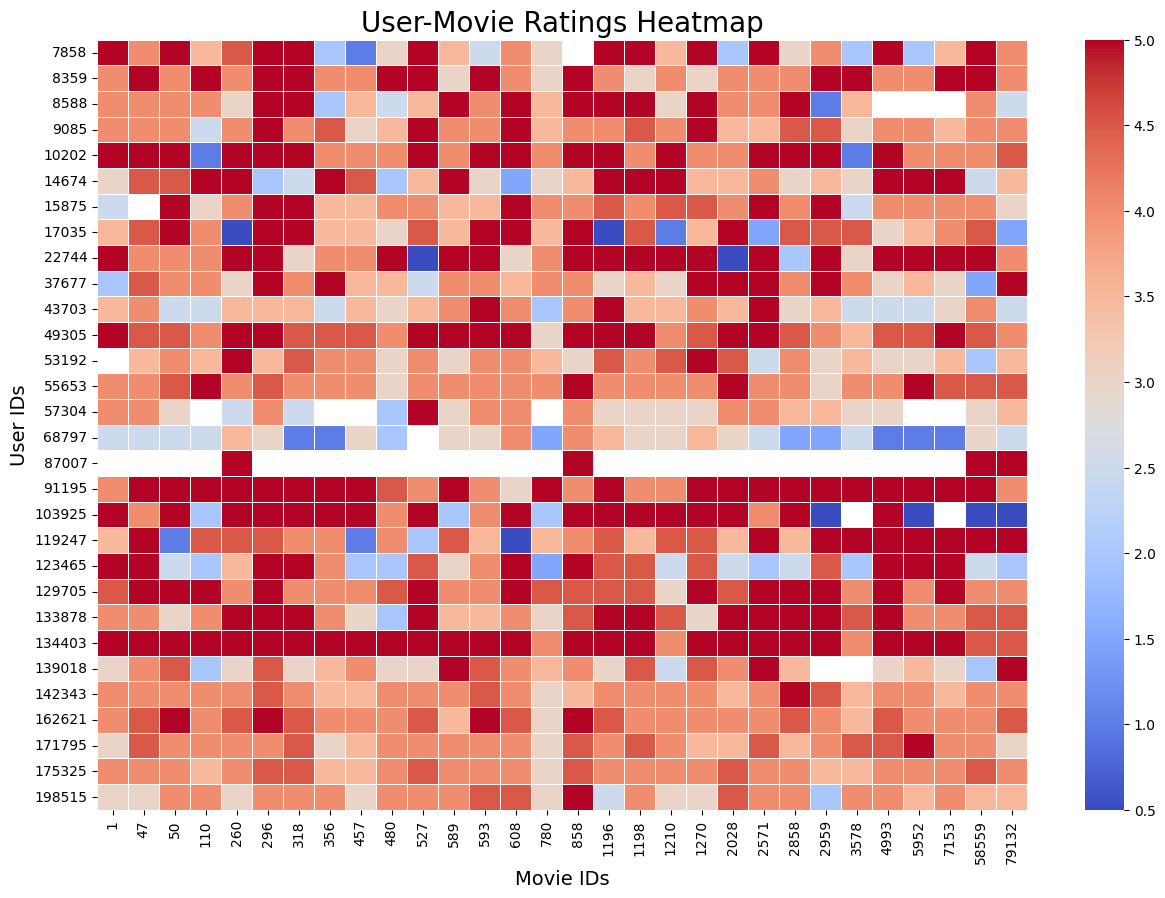

In [44]:
#heat map for  rating
import seaborn as sns
df_rating = pd.read_csv("ratings.csv", dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'})
top_movies = df_rating['movieId'].value_counts().head(30).index
top_users  = df_rating['userId'].value_counts().head(30).index

filtered = df_rating[
    df_rating['movieId'].isin(top_movies) &
    df_rating['userId'].isin(top_users)
    ]
movie_matrix = filtered.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

# Select smaller portion for visualization
heatmap_data = movie_matrix.iloc[:30, :30]

# Create Heatmap
plt.figure(figsize=(15,10))
sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    cbar=True
)

# Titles and Labels
plt.title("User-Movie Ratings Heatmap", fontsize=20)
plt.xlabel("Movie IDs", fontsize=14)
plt.ylabel("User IDs", fontsize=14)

plt.show()

In [45]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(tfidf_matrix, open('tfidf.pkl', 'wb'))
pickle.dump(movies_df, open('movies.pkl', 'wb'))


In [46]:
import os
print(os.getcwd())

C:\Users\Hp


In [50]:
movies_df['title'].values


array(['Toy Story (1995)', 'Jumanji (1995)', 'Grumpier Old Men (1995)',
       ..., 'Orca (2023)', 'The Angry Breed (1968)',
       'Race to the Summit (2023)'], shape=(87585,), dtype=object)

In [51]:
movies_df.to_dict()

{'movieId': {0: 1,
  1: 2,
  2: 3,
  3: 4,
  4: 5,
  5: 6,
  6: 7,
  7: 8,
  8: 9,
  9: 10,
  10: 11,
  11: 12,
  12: 13,
  13: 14,
  14: 15,
  15: 16,
  16: 17,
  17: 18,
  18: 19,
  19: 20,
  20: 21,
  21: 22,
  22: 23,
  23: 24,
  24: 25,
  25: 26,
  26: 27,
  27: 28,
  28: 29,
  29: 30,
  30: 31,
  31: 32,
  32: 33,
  33: 34,
  34: 35,
  35: 36,
  36: 37,
  37: 38,
  38: 39,
  39: 40,
  40: 41,
  41: 42,
  42: 43,
  43: 44,
  44: 45,
  45: 46,
  46: 47,
  47: 48,
  48: 49,
  49: 50,
  50: 51,
  51: 52,
  52: 53,
  53: 54,
  54: 55,
  55: 56,
  56: 57,
  57: 58,
  58: 59,
  59: 60,
  60: 61,
  61: 62,
  62: 63,
  63: 64,
  64: 65,
  65: 66,
  66: 67,
  67: 68,
  68: 69,
  69: 70,
  70: 71,
  71: 72,
  72: 73,
  73: 74,
  74: 75,
  75: 76,
  76: 77,
  77: 78,
  78: 79,
  79: 80,
  80: 81,
  81: 82,
  82: 83,
  83: 84,
  84: 85,
  85: 86,
  86: 87,
  87: 88,
  88: 89,
  89: 90,
  90: 92,
  91: 93,
  92: 94,
  93: 95,
  94: 96,
  95: 97,
  96: 98,
  97: 99,
  98: 100,
  99: 101,
  100:

In [52]:
pickle.dump(movies_df.to_dict(),open('movies_dict.pkl','wb'))